# Oscar — fixing the probabilities: scikit-learn's calibration example

3 Oct 2026. Rough working.

**Where this fits.** `07-yeh-lien` reproduced Yeh & Lien (2009) and found that the
logistic regression *ranks* customers about as well as the paper's, but its
*probabilities* are off in an S shape (step 5). This notebook takes a published,
runnable example on exactly that problem, runs it as published, then adapts it to
the Taiwan data to see whether the probabilities can be fixed.

**The resource.** *Probability Calibration curves*, an example in the scikit-learn
documentation, version 1.9.1 (the version installed here):
https://scikit-learn.org/stable/auto_examples/calibration/plot_calibration_curve.html
Source: `examples/calibration/plot_calibration_curve.py` in the scikit-learn
repository. Authors: the scikit-learn developers. Licence: BSD-3-Clause, which allows
reuse with the notice kept. It cites Niculescu-Mizil & Caruana (2005),
*Predicting good probabilities with supervised learning*, ICML.

**Why this one.** It compares logistic regression with **Gaussian naive Bayes**, and
naive Bayes is one of the six methods in Yeh & Lien. It fixes probabilities with
`CalibratedClassifierCV`, and scores them with the Brier score and **log loss**.

**Plan:**

* **Part A**: the example's naive Bayes half, run unchanged on its synthetic data
* **Part B**: the same method on the Taiwan data, with the changes listed there
* **Part C**: naive Bayes against the paper's results
* Notes

Some of the methods here were covered in another unit I've taken, *Statistical Machine
Learning* (MATH30028). The **"Link to MATH30028"** note at the end says where.
Reference: Maullin, T. (2026). *MATH30028 Statistical Machine Learning, Part I*, lecture notes, University of Bristol.

## Part A — the example, as published

The code cells below are copied **unchanged** from the example's first half. The
second half repeats the method with a linear support vector classifier, which
isn't one of the paper's methods, so it is left out. The example's own comments
are summarised in the markdown.

**Data.** A made-up (synthetic) dataset: 100,000 rows, 20 columns, of which only 2
carry signal, 10 are mixtures of those 2, and 8 are noise. It trains on 1,000 rows
and tests on the other 99,000.

In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=100_000, n_features=20, n_informative=2, n_redundant=10, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.99, random_state=42
)

**Models.** Logistic regression as a baseline, which the example says is usually
well calibrated already because it is fitted by minimising log loss. Then naive
Bayes, uncalibrated and with the two fixes offered by `CalibratedClassifierCV`:

* **sigmoid** (Platt scaling): fit a logistic curve from the model's score to the
  outcome;
* **isotonic**: fit any non-decreasing step function from the score to the outcome.

`cv=2` means each fix is fitted by cross-validation inside the training data.

In [2]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

lr = LogisticRegression(C=1.0)
gnb = GaussianNB()
gnb_isotonic = CalibratedClassifierCV(gnb, cv=2, method="isotonic")
gnb_sigmoid = CalibratedClassifierCV(gnb, cv=2, method="sigmoid")

clf_list = [
    (lr, "Logistic"),
    (gnb, "Naive Bayes"),
    (gnb_isotonic, "Naive Bayes + Isotonic"),
    (gnb_sigmoid, "Naive Bayes + Sigmoid"),
]

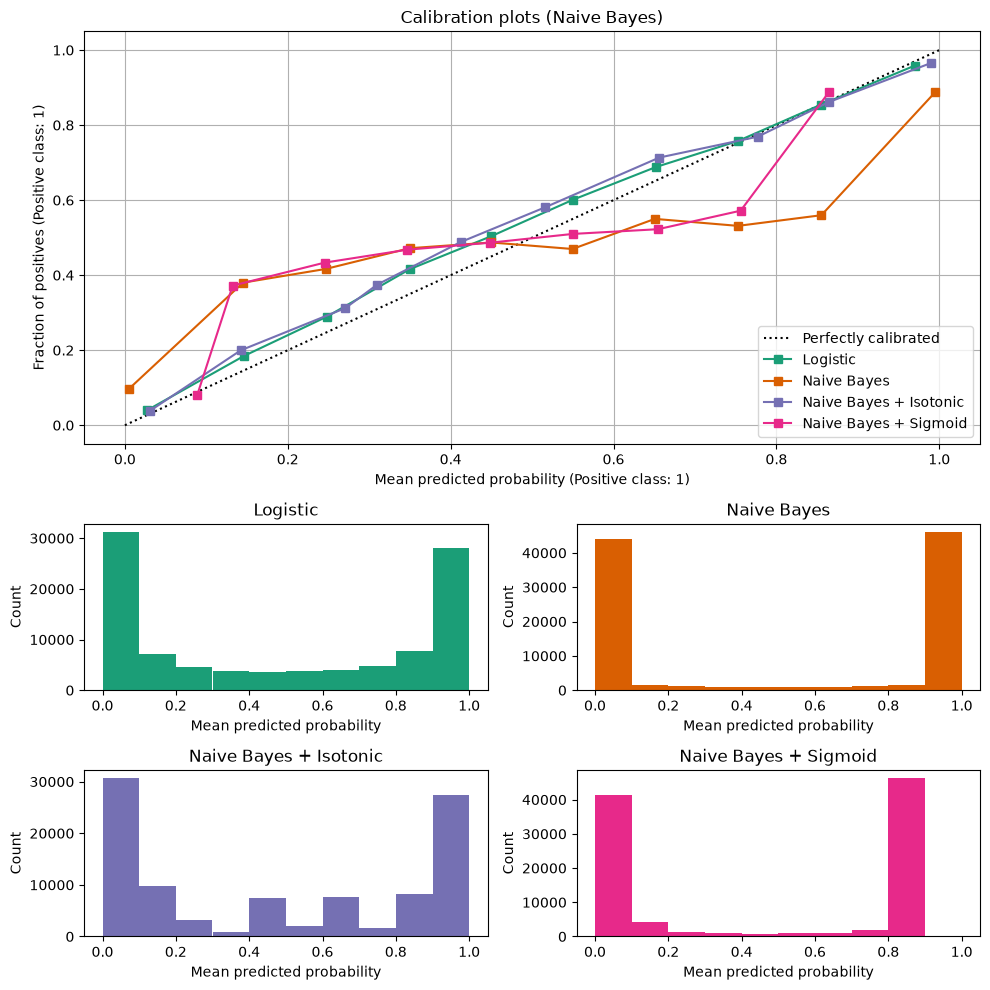

In [3]:
fig = plt.figure(figsize=(10, 10))
gs = GridSpec(4, 2)
colors = plt.get_cmap("Dark2")

ax_calibration_curve = fig.add_subplot(gs[:2, :2])
calibration_displays = {}
for i, (clf, name) in enumerate(clf_list):
    clf.fit(X_train, y_train)
    display = CalibrationDisplay.from_estimator(
        clf,
        X_test,
        y_test,
        n_bins=10,
        name=name,
        ax=ax_calibration_curve,
        color=colors(i),
    )
    calibration_displays[name] = display

ax_calibration_curve.grid()
ax_calibration_curve.set_title("Calibration plots (Naive Bayes)")

# Add histogram
grid_positions = [(2, 0), (2, 1), (3, 0), (3, 1)]
for i, (_, name) in enumerate(clf_list):
    row, col = grid_positions[i]
    ax = fig.add_subplot(gs[row, col])

    ax.hist(
        calibration_displays[name].y_prob,
        range=(0, 1),
        bins=10,
        label=name,
        color=colors(i),
    )
    ax.set(title=name, xlabel="Mean predicted probability", ylabel="Count")

plt.tight_layout()
plt.show()

**What the example says about this plot.** Uncalibrated naive Bayes is
*over-confident*: the 10 redundant columns break its assumption that columns are
independent, so it counts the same evidence many times and pushes probabilities
towards 0 and 1. That gives the "transposed sigmoid" curve. Isotonic calibration
fixes it almost completely; sigmoid helps only a little.

**The metrics.** Brier score and log loss judge the probabilities; ROC AUC judges
the ranking; precision, recall and F1 judge the yes/no predictions at threshold 0.5.

In [4]:
from collections import defaultdict

import pandas as pd

from sklearn.metrics import (
    brier_score_loss,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)

scores = defaultdict(list)
for i, (clf, name) in enumerate(clf_list):
    clf.fit(X_train, y_train)
    y_prob = clf.predict_proba(X_test)
    y_pred = clf.predict(X_test)
    scores["Classifier"].append(name)

    for metric in [brier_score_loss, log_loss, roc_auc_score]:
        score_name = metric.__name__.replace("_", " ").replace("score", "").capitalize()
        scores[score_name].append(metric(y_test, y_prob[:, 1]))

    for metric in [precision_score, recall_score, f1_score]:
        score_name = metric.__name__.replace("_", " ").replace("score", "").capitalize()
        scores[score_name].append(metric(y_test, y_pred))

    score_df = pd.DataFrame(scores).set_index("Classifier")
    score_df.round(decimals=3)

score_df

,Brier loss,Log loss,Roc auc,Precision,Recall,F1
Classifier,,,,,,
Logistic,0.098932,0.323200,0.937443,0.871965,0.851348,0.861533
Naive Bayes,0.117608,0.782755,0.940373,0.857400,0.875941,0.866571
Naive Bayes + Isotonic,0.098332,0.370738,0.938613,0.883065,0.836224,0.859007
Naive Bayes + Sigmoid,0.108880,0.368896,0.940201,0.861106,0.871277,0.866161


**What the example concludes.** Calibration improves the Brier score and log loss
but barely changes precision, recall and F1, because it shouldn't move
probabilities much near the 0.5 threshold. ROC AUC "should not change at all
because calibration is a monotonic transformation". Its summary: sigmoid
calibration can fix a sigmoid-shaped curve but **not** a transposed-sigmoid one
(naive Bayes's); isotonic can fix both, but may need more data.

The example ran as published. The plot and table match the ones on the
documentation page.

## Part B — the same method on the Taiwan data

What changes, and why:

1. **The data**: the cleaned Taiwan file and the **same three-way split as `07`**
   (same seeds), so the results line up with `07`.
2. **The logistic regression is the paper's** (no penalty, `C=np.inf`, scaled), as
   in `07` step 1, rather than the example's `C=1.0`. `07` showed this makes no
   practical difference.
3. **Calibrate on the calibration set, not by cross-validation.** The example's
   `cv=2` refits the model inside its training data. We already set aside a
   calibration set for exactly this job in `07` step 0. So we fit each model on
   **train**, freeze it (`FrozenEstimator`, so `CalibratedClassifierCV` can't refit
   it), and fit only the sigmoid or isotonic correction on the **calibration**
   set. Everything is scored on the **test** set.
4. **Calibration curves use 10 equal-size groups** (`strategy="quantile"`), as in
   `07` step 5, instead of the example's 10 equal-width bins. Most customers have
   p between 0.1 and 0.3, so equal-width bins would leave most bins nearly empty.
5. **Our colours and layout**, matching `07`. Each line also has its own marker,
   so the plot doesn't rely on colour alone.

In [5]:
from pathlib import Path
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.frozen import FrozenEstimator

ROOT = Path.cwd().parent
taiwan = pd.read_csv(ROOT / "data" / "processed" / "taiwan-clean.csv", index_col="ID")
Y = "default payment next month"
BLUE, ORANGE, GREY, GREEN = "#2a78d6", "#eb6834", "#8a8984", "#1a9e77"

# Same split as 07: 60% train, 20% calibration, 20% test. (This replaces Part A's X and y.)
X = taiwan.drop(columns=Y)
y = taiwan[Y]
X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=0)
X_train, X_cal, y_train, y_cal = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest, random_state=0)

# 1. Fit the two base models on TRAIN.
logistic = make_pipeline(StandardScaler(), LogisticRegression(C=np.inf, max_iter=5000))
naive_bayes = GaussianNB()
logistic.fit(X_train, y_train)
naive_bayes.fit(X_train, y_train)

# 2. Freeze each one and fit only the correction on the CALIBRATION set.
models = {}
for base, name in [(logistic, "Logistic"), (naive_bayes, "Naive Bayes")]:
    models[name] = base
    for method in ["isotonic", "sigmoid"]:
        fixed = CalibratedClassifierCV(FrozenEstimator(base), method=method)
        models[f"{name} + {method.capitalize()}"] = fixed.fit(X_cal, y_cal)

# 3. Predicted probabilities on the TEST set, for every model.
p_test = {name: m.predict_proba(X_test)[:, 1] for name, m in models.items()}
list(models)

['Logistic',
 'Logistic + Isotonic',
 'Logistic + Sigmoid',
 'Naive Bayes',
 'Naive Bayes + Isotonic',
 'Naive Bayes + Sigmoid']

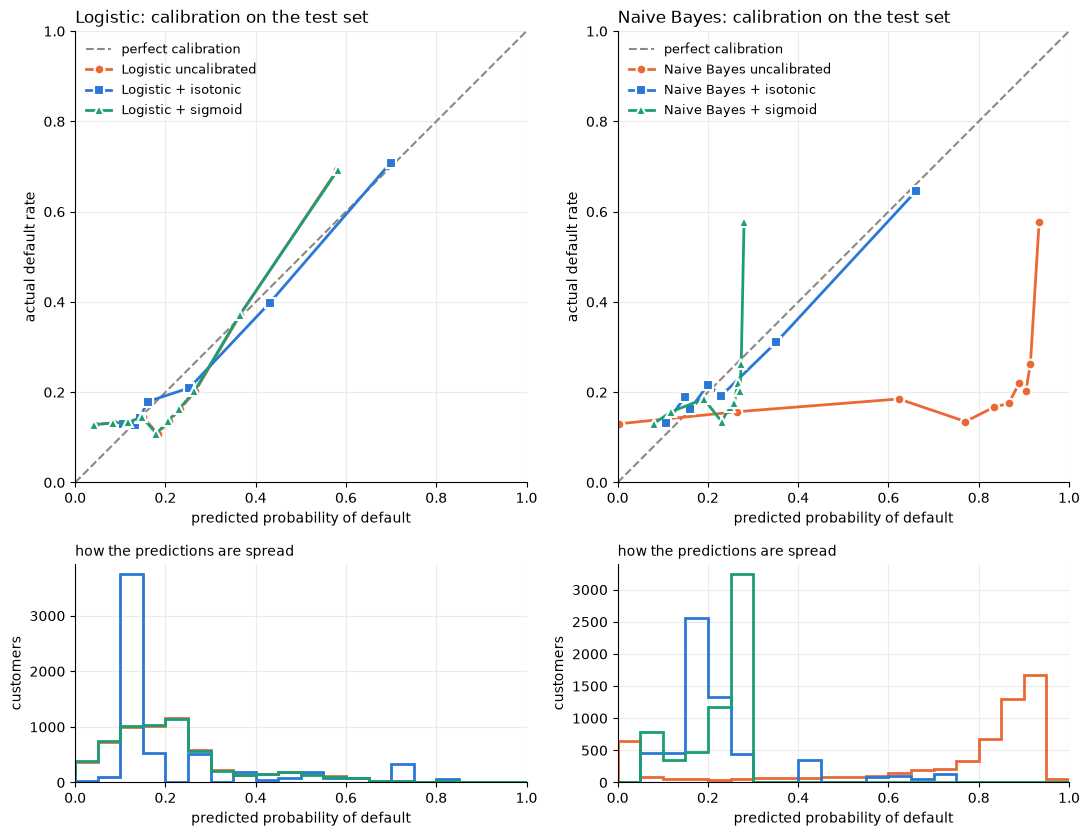

In [6]:
STYLE = {"":            (ORANGE, "o", "uncalibrated"),
         " + Isotonic": (BLUE,   "s", "+ isotonic"),
         " + Sigmoid":  (GREEN,  "^", "+ sigmoid")}

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5), gridspec_kw={"height_ratios": [2.2, 1]})
for col, base in enumerate(["Logistic", "Naive Bayes"]):
    ax, hx = axes[0, col], axes[1, col]
    ax.plot([0, 1], [0, 1], color=GREY, linestyle="--", linewidth=1.5, label="perfect calibration")
    for suffix, (colour, marker, label) in STYLE.items():
        p = p_test[base + suffix]
        frac, mean_p = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
        ax.plot(mean_p, frac, marker=marker, color=colour, linewidth=2, markersize=7,
                markeredgecolor="white", markeredgewidth=1.5, label=f"{base} {label}")
        hx.hist(p, bins=20, range=(0, 1), histtype="step", linewidth=2, color=colour)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
    ax.set_title(f"{base}: calibration on the test set", loc="left")
    ax.set_xlabel("predicted probability of default")
    ax.set_ylabel("actual default rate")
    ax.legend(frameon=False, loc="upper left", fontsize=9)
    hx.set_xlim(0, 1)
    hx.set_xlabel("predicted probability of default")
    hx.set_ylabel("customers")
    hx.set_title("how the predictions are spread", loc="left", fontsize=10)
    for a in (ax, hx):
        a.spines[["top", "right"]].set_visible(False)
        a.grid(color="0.92"); a.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Reading the plot.** Top: each model's 10 groups, average prediction against
actual default rate; on the dashed line is perfect. Bottom: how many test
customers get each predicted probability. Isotonic curves can show fewer than 10
points, because isotonic maps customers onto a few dozen distinct values, and
groups that share a value merge.

**The example's metric table**, on the Taiwan test set, plus three columns of
ours: the Brier score of predicting 22% for everyone (a yardstick), the share of
customers flagged at 0.5, and the paper's error rate.

In [7]:
rows = {}
for name, m in models.items():
    p = p_test[name]
    flag = m.predict(X_test)                      # yes/no at threshold 0.5, as in the example
    rows[name] = {
        "Brier": brier_score_loss(y_test, p),
        "Log loss": log_loss(y_test, p),
        "Roc auc": roc_auc_score(y_test, p),
        # zero_division=0: a model that flags nobody has no precision; report 0 instead of an error.
        "Precision": precision_score(y_test, flag, zero_division=0),
        "Recall": recall_score(y_test, flag),
        "F1": f1_score(y_test, flag, zero_division=0),
        "share flagged": flag.mean(),
        "error rate": np.mean(flag != y_test),
    }
results = pd.DataFrame(rows).T
print(f"Brier score of predicting {y_train.mean():.1%} for everyone: "
      f"{brier_score_loss(y_test, np.full(len(y_test), y_train.mean())):.3f}")
results.round(3)

Brier score of predicting 22.1% for everyone: 0.172


,Brier,Log loss,Roc auc,Precision,Recall,F1,share flagged,error rate
Logistic,0.146,0.470,0.712,0.724,0.246,0.367,0.075,0.188
Logistic + Isotonic,0.141,0.474,0.715,0.678,0.361,0.471,0.118,0.179
Logistic + Sigmoid,0.146,0.471,0.712,0.726,0.247,0.369,0.075,0.187
Naive Bayes,0.462,1.515,0.652,0.240,0.864,0.375,0.796,0.636
Naive Bayes + Isotonic,0.156,0.490,0.650,0.646,0.192,0.296,0.066,0.202
Naive Bayes + Sigmoid,0.169,0.520,0.652,0.000,0.000,0.000,0.000,0.221


## Part C — naive Bayes against the paper

Yeh & Lien report naive Bayes too. Their Table 1 gives an error rate of 0.21 and an
area ratio of **0.53** on validation data (better than their logistic regression's
0.44). Their Table 2 gives the Sorting Smoothing Method line real = A + B × predicted
with **B = 0.502, A = 0.0901, R² = 0.899**.

We compute the same for ours. The area ratio is 2 × AUC − 1 (shown in `07` step 2).
The `ssm_line` function is copied from `07` step 5.

In [8]:
def ssm_line(y_true, p, n=50):
    """Yeh & Lien's Sorting Smoothing Method and straight-line fit (copied from 07, step 5)."""
    order = np.argsort(p, kind="stable")
    p_sorted, y_sorted = p[order], np.asarray(y_true)[order]
    window = 2 * n + 1
    real = np.convolve(y_sorted, np.ones(window) / window, mode="valid")
    pred = p_sorted[n:len(p_sorted) - n]
    B, A = np.polyfit(pred, real, 1)
    return {"slope B": B, "intercept A": A, "R²": np.corrcoef(pred, real)[0, 1] ** 2}

paper = {
    "Logistic (Yeh & Lien)":    {"error rate": 0.18, "area ratio": 0.44, "slope B": 1.233, "intercept A": -0.0523, "R²": 0.794},
    "Naive Bayes (Yeh & Lien)": {"error rate": 0.21, "area ratio": 0.53, "slope B": 0.502, "intercept A": 0.0901,  "R²": 0.899},
}
ours = {f"{name} (ours)": {"error rate": results.loc[name, "error rate"],
                           "area ratio": 2 * results.loc[name, "Roc auc"] - 1,
                           **ssm_line(y_test, p_test[name])}
        for name in ["Logistic", "Logistic + Isotonic", "Naive Bayes", "Naive Bayes + Isotonic"]}
pd.DataFrame({**paper, **ours}).T.round(3)

,error rate,area ratio,slope B,intercept A,R²
Logistic (Yeh & Lien),0.180,0.440,1.233,-0.052,0.794
Naive Bayes (Yeh & Lien),0.210,0.530,0.502,0.090,0.899
Logistic (ours),0.188,0.425,1.119,-0.028,0.808
Logistic + Isotonic (ours),0.179,0.430,0.979,0.004,0.938
Naive Bayes (ours),0.636,0.303,0.170,0.098,0.167
Naive Bayes + Isotonic (ours),0.202,0.300,0.883,0.025,0.904


### Notes

**Part A.** The example ran as published: every number in its table matches the
documentation page to six decimal places.

**Part B, logistic regression: isotonic calibration fixes the S shape.**

* On the test set, isotonic moves the paper's straight-line summary (Part C) from
  slope 1.12 / intercept −0.03 to **0.98 / 0.00**, close to the ideal 1 / 0, and the
  10 groups now lie near the diagonal. The Brier score improves from 0.146 to
  **0.141**. Both the correction and the check use data the model never trained on
  (calibration set, then test set).
* Log loss gets very slightly *worse* (0.470 → 0.474). Isotonic is a step function
  fitted to 6,000 customers, so at the extremes its steps rest on few customers,
  and log loss punishes confident mistakes hard. The Brier score is less sensitive
  to that. The two measures can disagree, and the choice between them is a
  judgement.
* **Sigmoid calibration does almost nothing here** (Brier 0.146 both ways; the green
  and orange curves overlap). Sigmoid calibration fits a logistic curve to the
  model's score, and a logistic regression's output is already a logistic curve of
  a linear score, so it can only stretch it. It can't bend it into the S-shaped
  correction we need. This fits the example's own summary: sigmoid can only fix one
  particular shape.
* ROC AUC moved slightly with isotonic (0.712 → 0.715), although the example says
  calibration doesn't change rank measures. Isotonic is *non-decreasing*, not
  strictly increasing: it maps 6,000 customers onto a few dozen values, creating
  ties, and AUC counts ties as half. The principle holds, but not to three decimal
  places.
* **Calibration changes what the 0.5 threshold means.** After isotonic, 11.8% of
  customers are above 0.5 (7.5% before). Recall at 0.5 rises from 0.25 to 0.36,
  and the error rate falls to **0.179**, just below the paper's 0.18. The model's
  ranking hasn't changed; only the scale of its scores has. This is the same
  lesson as `07` step 4: a threshold is a choice, not part of the model.

**Part B, naive Bayes: very badly calibrated, and only partly fixable.**

* Gaussian naive Bayes gives most customers a probability between 0.8 and 0.95
  (bottom-right histogram), although 22% default. It flags 80% of customers at
  0.5, and its Brier score (0.462) is **worse than predicting 22% for everyone**
  (0.172). This is the over-confidence the example describes. The likely cause is
  the same: naive Bayes treats columns as independent, but the six bill columns
  overlap heavily (correlations 0.73–0.91 in `03-predictors`), so the same
  evidence is counted several times. The money columns are also very skewed,
  far from the bell curves Gaussian naive Bayes assumes.
* **Sigmoid can't fix it.** Its largest prediction is about 0.30, so at 0.5 it
  flags nobody (precision 0 by convention, error rate 0.221 = the default rate).
  This is exactly the example's warning that sigmoid can't fix naive Bayes's
  transposed-sigmoid curve, now seen on real data.
* **Isotonic rescues the probabilities but not the ranking.** Brier falls to 0.156
  and the straight-line summary becomes 0.88 / 0.03. But AUC stays at 0.65, below
  logistic regression's 0.71, because calibration doesn't reorder customers. So
  calibrated naive Bayes is still worse than logistic regression on every
  measure here.

**Part C: we could not reproduce the paper's naive Bayes. A dead end, but
an informative one.**

* The paper's naive Bayes has an area ratio of **0.53**, *better* than its logistic
  regression (0.44). Ours has **0.30**, much worse. Its line is B = 0.502, R² = 0.899;
  ours (uncalibrated) is 0.17 and 0.17. Our logistic regression matches the paper
  closely, so the data and split aren't the problem. The method is.
* The paper says only "naive Bayesian classifier". It doesn't say how the money
  columns were handled. Naive Bayes can treat them as bell curves (as
  scikit-learn's `GaussianNB` does) or cut them into bands first, and the two can
  behave very differently on skewed columns. We can't tell which the paper did.
* **So the paper's ranking of methods doesn't transfer to the scikit-learn
  version of the same method.** A method's name isn't enough to reproduce a
  result: the implementation details matter, and a paper without code doesn't
  give them. That is an argument for publishing code, and for the brief's
  question on sharing code via GitHub.

**Resources used here:** the scikit-learn example (run, then adapted);
Niculescu-Mizil & Caruana (2005), cited by the example; Yeh & Lien (2009).

> **Link to MATH30028 (SML).** * **Sigmoid (Platt) calibration is itself a logistic regression** (§2.3.8, Example 3),
  with the model's score as the single covariate. Applied to a logistic regression,
  it gives a logistic of a linear function of an already-linear score, so it can only
  rescale. That is why it barely changed our logistic model.
* **Isotonic calibration is piecewise-constant regression** (§2.3.3, "histogram
  regression") with the knots chosen from the data and the steps forced to be
  non-decreasing. That is why it outputs only a few dozen distinct values.
* **Naive Bayes is a generative classifier; logistic regression is discriminative**
  (§3.1.5). Naive Bayes models each column given the class, then uses Bayes' rule.
  Logistic regression models P(default | x) directly.
* **Why Gaussian naive Bayes fails here** (§3.3.4). It assumes (1) each column is
  Gaussian within each class, and (2) columns are **conditionally independent** given
  the class (Remark 12, which warns this is often unrealistic). The skewed money
  columns break (1) and the near-duplicate bill columns break (2). LDA (§3.3.1) keeps
  the Gaussian assumption but models the correlations.
* **Part C, a possible explanation for the paper's result:** naive Bayes is often run
  with *categorical* distributions for banded or discrete columns, using Laplace
  smoothing for empty bands (§3.3.4, Lemma 28). Banding would remove the skew problem.
  This is a hypothesis, not something the paper states.